In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
# index is in the datafram, data is seperate by ; , decimal is comma
data = pd.read_csv('Scores.csv', index_col=0, sep=';', decimal=',')

In [3]:
data.head()

,student_id,gender,parental.level.of.education,subject,score
1,id_001,female,high school,math,23.0
2,id_001,female,high school,language,40.0
3,id_002,female,high school,math,68.0
4,id_002,female,high school,language,80.5
5,id_003,male,high school,math,82.0


# 1) Descriptive Analysis of the Dataset

In [4]:
# Check for null values
data.isnull().sum() # no vull values

student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64

In [5]:
data.describe(include='all')

,student_id,gender,parental.level.of.education,subject,score
count,972,972,972,972,972.000000
unique,486,2,4,2,NaN
top,id_001,female,associate's degree,math,NaN
freq,2,490,354,486,NaN
mean,NaN,NaN,NaN,NaN,67.690844
std,NaN,NaN,NaN,NaN,14.804105
min,NaN,NaN,NaN,NaN,19.500000
25%,NaN,NaN,NaN,NaN,57.000000
50%,NaN,NaN,NaN,NaN,68.000000
75%,NaN,NaN,NaN,NaN,78.000000


In [6]:
# rename parental.level.of.education
data.rename(columns={'parental.level.of.education': 'parental_level_of_education'}, inplace=True)

In [7]:
# Question: How many students
n_student = data.student_id.nunique()
print(f'The number of students is: {n_student}') # Meaning for each student we have math and language scores.

The number of students is: 486


In [8]:
# Question: Check fore male/female students
data.gender.value_counts() # number of students in gender groups are close to each other.

gender
female    490
male      482
Name: count, dtype: int64

In [9]:
data.parental_level_of_education.value_counts()

parental_level_of_education
associate's degree    354
high school           312
bachelor's degree     188
master's degree       118
Name: count, dtype: int64

### Check features 1: Parentel Level of Education

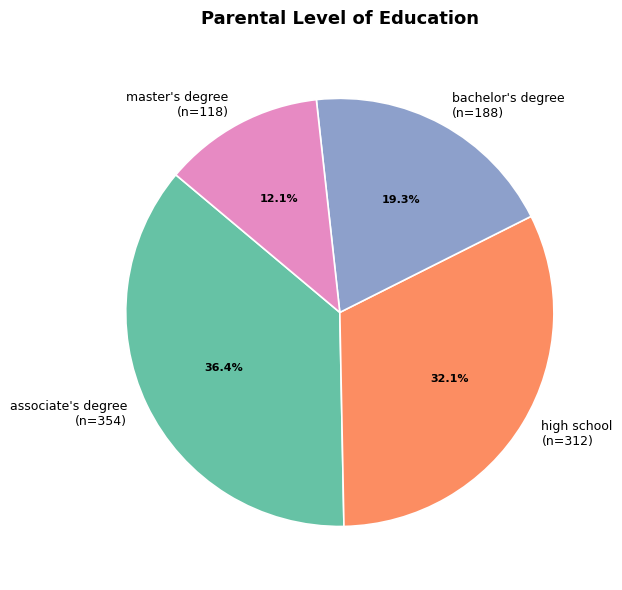

In [10]:
# Pie plot for parental level of education
counts = data.parental_level_of_education.value_counts()
labels = [f'{idx}\n(n={val})' for idx, val in zip(counts.index, counts.values)]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)

for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

ax.set_title('Parental Level of Education', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Check features 2: Math and Language Scores

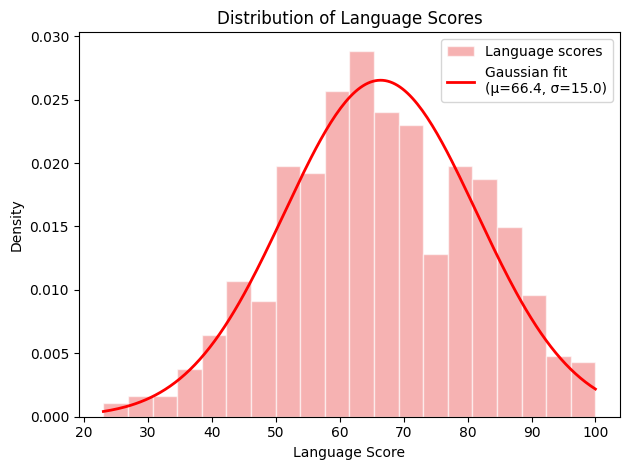

In [11]:
# Check the distribution of scores with fitted Gaussian for language scores
math_scores = data[data['subject'] == 'math']['score']
mu_lang, std_lang = stats.norm.fit(math_scores)
x_lang = np.linspace(math_scores.min(), math_scores.max(), 200)
plt.hist(math_scores, bins=20, density=True, alpha=0.6, color='lightcoral', edgecolor='white', label='Language scores')
plt.plot(x_lang, stats.norm.pdf(x_lang, mu_lang, std_lang), 'r-', linewidth=2, label=f'Gaussian fit\n(μ={mu_lang:.1f}, σ={std_lang:.1f})')
plt.title('Distribution of Language Scores')
plt.xlabel('Language Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()

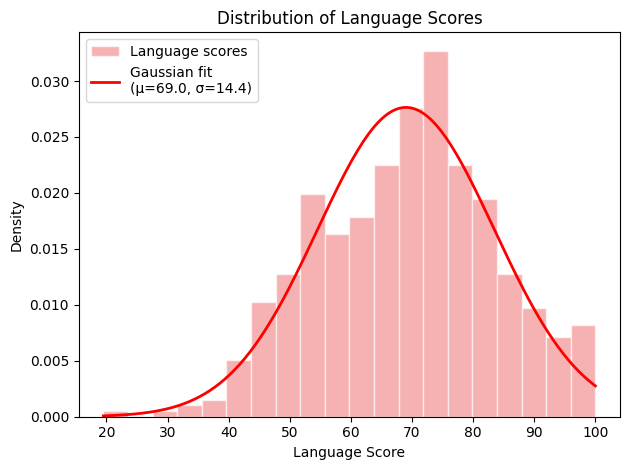

In [12]:
# Check the distribution of scores with fitted Gaussian for language scores
language_scores = data[data['subject'] == 'language']['score']
mu_lang, std_lang = stats.norm.fit(language_scores)
x_lang = np.linspace(language_scores.min(), language_scores.max(), 200)
plt.hist(language_scores, bins=20, density=True, alpha=0.6, color='lightcoral', edgecolor='white', label='Language scores')
plt.plot(x_lang, stats.norm.pdf(x_lang, mu_lang, std_lang), 'r-', linewidth=2, label=f'Gaussian fit\n(μ={mu_lang:.1f}, σ={std_lang:.1f})')
plt.title('Distribution of Language Scores')
plt.xlabel('Language Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()

NOTE: there is little bit left skewness (negative skew): meaning there is a more concentration on higher scores for language.
Same for math, but its less 

In [13]:
def describe_statistics(score):
    mean = np.mean(score)
    median = np.median(score)
    std_dev = np.std(score, ddof=1)  # Sample standard deviation
    return mean, median, std_dev

math_stats = describe_statistics(math_scores)
language_stats = describe_statistics(language_scores)

print(f'Math Scores - Mean: {math_stats[0]:.2f}, Median: {math_stats[1]:.2f}, Std Dev: {math_stats[2]:.2f}')
print(f'Language Scores - Mean: {language_stats[0]:.2f}, Median: {language_stats[1]:.2f}, Std Dev: {language_stats[2]:.2f}')



Math Scores - Mean: 66.38, Median: 66.00, Std Dev: 15.05
Language Scores - Mean: 69.00, Median: 70.00, Std Dev: 14.45


NOTE: Mean and median close to each other, meaning dataset is roughly symmetric and has low skewness

/var/folders/ym/hcyz4chn3cq4n_8dslg5k50h0000gn/T/ipykernel_38409/543898777.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


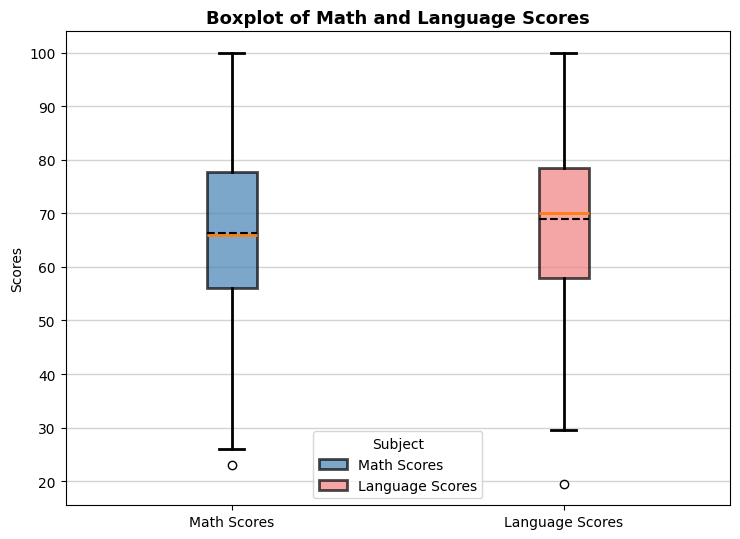

In [14]:

fig, ax = plt.subplots(figsize=(7.5, 5.5))

bp = ax.boxplot(
    [math_scores, language_scores],
    labels=['Math Scores', 'Language Scores'],
    patch_artist=True,
    showmeans=True,
    meanline=True,
)

colors = ['steelblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_linewidth(2)

for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_linewidth(2)

for mean in bp['means']:
    mean.set_color('black')
    mean.set_linewidth(1.5)
    mean.set_linestyle('--')

ax.set_title('Boxplot of Math and Language Scores', fontsize=13, fontweight='bold')
ax.set_ylabel('Scores')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')
ax.legend(
    [bp['boxes'][0], bp['boxes'][1]],
    ['Math Scores', 'Language Scores'],
    title='Subject',
)

plt.tight_layout()
plt.show()


In [15]:
# So for scores: language scores are slightly higher than math scores on average,
# but the distributions are quite similar. Both subjects show a fairly normal distribution with some variability,
# and there are no extreme outliers in either case.

In [16]:
# Lookign to the boxplot, we can see 1 data point for math scores and 1 data point for language scores is outlier regarding to iqr range

# 

In [17]:
# find the outliers for math scores
Q1_math = np.percentile(math_scores, 25)
Q3_math = np.percentile(math_scores, 75)
IQR_math = Q3_math - Q1_math 
lower_bound_math = Q1_math - 1.5 * IQR_math
upper_bound_math = Q3_math + 1.5 * IQR_math
outliers_math = math_scores[(math_scores < lower_bound_math) | (math_scores > upper_bound_math)]
print(f'Math score outliers: {outliers_math.values}')

Math score outliers: [23.]


In [18]:
# find outliers for language scores
Q1_lang = np.percentile(language_scores, 25)
Q3_lang = np.percentile(language_scores, 75)
IQR_lang = Q3_lang - Q1_lang
lower_bound_lang = Q1_lang - 1.5 * IQR_lang
upper_bound_lang = Q3_lang + 1.5 * IQR_lang
outliers_lang = language_scores[(language_scores < lower_bound_lang) | (language_scores > upper_bound_lang)]
print(f'Language score outliers: {outliers_lang.values}')

Language score outliers: [19.5]


In [19]:
# keep outliers for now

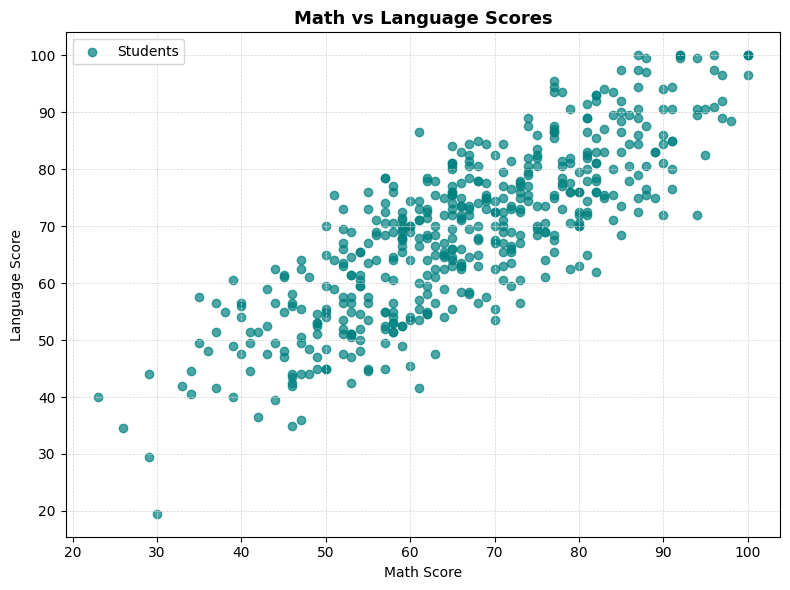

In [20]:
# plot language-math scores for each student
math_scores = data[data['subject'] == 'math']['score']
language_scores = data[data['subject'] == 'language']['score']
plt.figure(figsize=(8, 6))
plt.scatter(math_scores, language_scores, alpha=0.7, color='teal', label='Students')
plt.title('Math vs Language Scores', fontsize=13, fontweight='bold')
plt.xlabel('Math Score')
plt.ylabel('Language Score')
plt.grid(True, color='lightgrey', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

In [21]:
# Note: There is a positive correlation between math and language scores in generall

coeff = np.corrcoef(math_scores, language_scores)[0, 1] # Pearson product-moment correlation coefficients.
print(f'Correlation coefficient between math and language scores: {coeff:.2f}') # 0.82 meaning high correlation

Correlation coefficient between math and language scores: 0.82


# Research Question 1: Is there a statistically significant difference between male and female students in their Mathematics scores and in their Language scores?

#### 1.1: Math Score - Gender

In [22]:
math_female = data[(data['subject'] == 'math') & (data['gender'] == 'female')]['score']
math_male = data[(data['subject'] == 'math') & (data['gender'] == 'male')]['score']

In [23]:
female_math_stats = describe_statistics(math_female)
male_math_stats = describe_statistics(math_male)

# print the statistics
print(f'Female Math Scores - Mean: {female_math_stats[0]:.2f}, Median: {female_math_stats[1]:.2f}, Std Dev: {female_math_stats[2]:.2f}')
print(f'Male Math Scores - Mean: {male_math_stats[0]:.2f}, Median: {male_math_stats[1]:.2f}, Std Dev: {male_math_stats[2]:.2f}')


Female Math Scores - Mean: 63.86, Median: 64.00, Std Dev: 15.26
Male Math Scores - Mean: 68.95, Median: 70.00, Std Dev: 14.43


/var/folders/ym/hcyz4chn3cq4n_8dslg5k50h0000gn/T/ipykernel_38409/2126538232.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


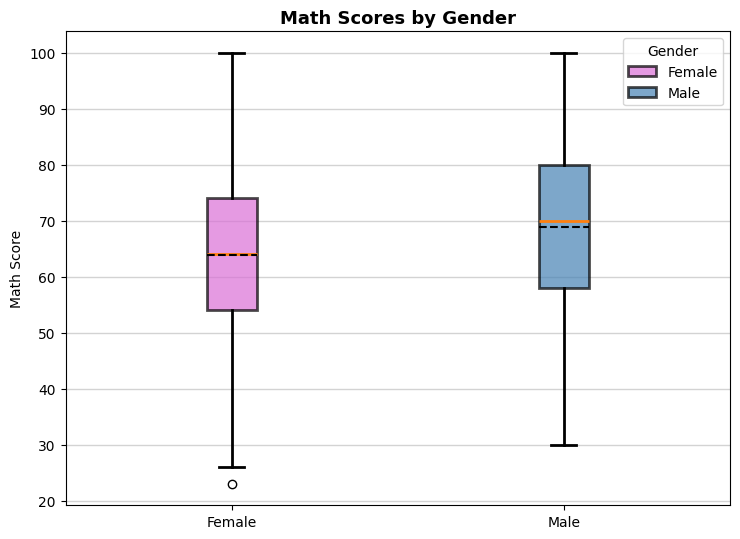

In [24]:
# box plot for math scores by gender
fig, ax = plt.subplots(figsize=(7.5, 5.5))

bp = ax.boxplot(
    [math_female, math_male],
    labels=['Female', 'Male'],
    patch_artist=True,
    showmeans=True,
    meanline=True,
)

colors = ['orchid', 'steelblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_linewidth(2)

for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_linewidth(2)

for mean in bp['means']:
    mean.set_color('black')
    mean.set_linewidth(1.5)
    mean.set_linestyle('--')

ax.set_title('Math Scores by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Math Score')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')
ax.legend(
    [bp['boxes'][0], bp['boxes'][1]],
    ['Female', 'Male'],
    title='Gender',
)

plt.tight_layout()
plt.show()


### Note: There is a difference in mean between female and male scores in math. Explore it further

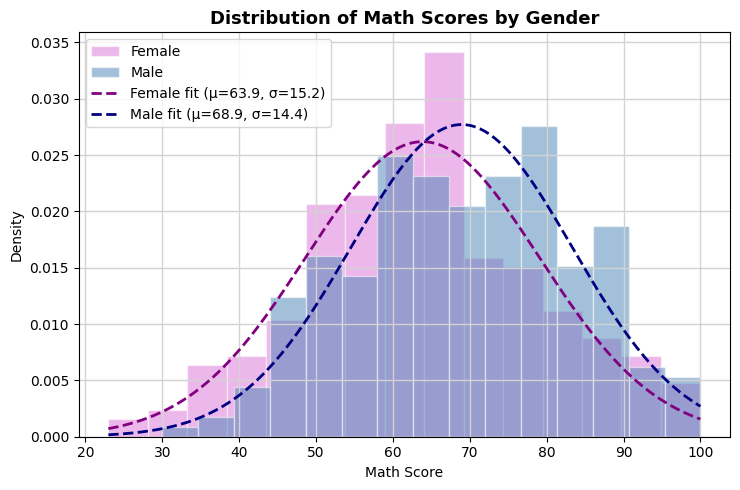

In [25]:
# Histogram of math scores by gender
fig, ax = plt.subplots(figsize=(7.5, 5))

mu_f, std_f = stats.norm.fit(math_female)
mu_m, std_m = stats.norm.fit(math_male)
x_range = np.linspace(min(math_female.min(), math_male.min()), max(math_female.max(), math_male.max()), 200)

ax.hist(math_female, bins=15, density=True, alpha=0.5, color='orchid', edgecolor='white', label='Female')
ax.hist(math_male, bins=15, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Male')
ax.plot(x_range, stats.norm.pdf(x_range, mu_f, std_f), color='purple', linewidth=2, linestyle='--', label=f'Female fit (μ={mu_f:.1f}, σ={std_f:.1f})')
ax.plot(x_range, stats.norm.pdf(x_range, mu_m, std_m), color='navy', linewidth=2, linestyle='--', label=f'Male fit (μ={mu_m:.1f}, σ={std_m:.1f})')

ax.set_title('Distribution of Math Scores by Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Math Score')
ax.set_ylabel('Density')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.xaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')
ax.legend()
plt.tight_layout()
plt.show()


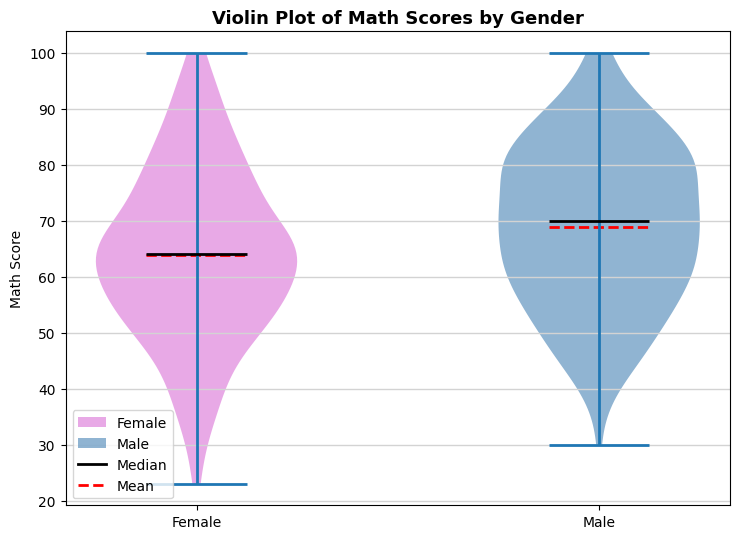

In [26]:
# Violin plot of math scores by gender
fig, ax = plt.subplots(figsize=(7.5, 5.5))

parts = ax.violinplot(
    [math_female, math_male],
    positions=[1, 2],
    showmedians=True,
    showmeans=True,
    showextrema=True,
)

colors = ['orchid', 'steelblue']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

for part in ['cmedians', 'cmeans', 'cbars', 'cmaxes', 'cmins']:
    parts[part].set_linewidth(2)

parts['cmedians'].set_color('black')
parts['cmeans'].set_color('red')
parts['cmeans'].set_linestyle('--')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Female', 'Male'])
ax.set_title('Violin Plot of Math Scores by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Math Score')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='orchid', alpha=0.6, label='Female'),
    Patch(facecolor='steelblue', alpha=0.6, label='Male'),
    Line2D([0], [0], color='black', linewidth=2, label='Median'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Mean'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


## Hypotosesis Testing: Gender vs Math Score

### H0: There is no statistical difference between male and female students in their Math Scores
### H1: There is a significance difference between male and female students in their Math Scores

In [27]:
# Now we need to use the data in order to find evicende for or against null hypothesis
# Null hypothesis: There is no significant difference in math scores between male and female students.
# We need a test statistics.

# The way in which we construct T depents on the nature of the null hypothesis that we are testing.
# X_m = math_m_1, math_m_2, math_m_3, math_m_4, math_m_5, math_m_6, math_m_7 ... math_m_n denote the math scores of male students
# X_f = math_f_1, math_f_2, math_f_3, math_f_4, math_f_5, math_f_6, math_f_7 ... math_f_n denote the math scores of female students
# E(X_m) = mean_x_m, E(X_f) = mean_x_f. Under H0: E(X_m) = E(X_f) meaning mean_x_m = mean_x_f

# For this test we can use two-sample t-test to compare the means of math scores between male and female students. 

In [28]:
X_m = math_male
X_f = math_female

In [29]:
# two sample t-test assumes that the data is normally distributed and the variances of the two groups are equal. 
# We can check these assumptions before performing the test.

# Check for normality using Shapiro-Wilk test
from scipy.stats import shapiro

# Shapiro-Wilk test for male students
stat, p = shapiro(X_m) # H0: the data is normally distributed, H1: the data is not normally distributed
print('Shapiro-Wilk Test for Male Students: Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

# Shapiro-Wilk test for female students
stat, p = shapiro(X_f) # H0: the data is normally distributed, H1: the data is not normally distributed
print('Shapiro-Wilk Test for Female Students: Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Shapiro-Wilk Test for Male Students: Statistics=0.988, p=0.050
Sample looks Gaussian (fail to reject H0)
Shapiro-Wilk Test for Female Students: Statistics=0.994, p=0.501
Sample looks Gaussian (fail to reject H0)


In [30]:
from scipy.stats import levene

# check for equal variances using Levene's test
stat, p = levene(X_m, X_f) # H0: the variances are equal, H1: the variances are not equal
print('Levene’s Test: Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Variances are equal (fail to reject H0)')
else:
    print('Variances are not equal (reject H0)')

Levene’s Test: Statistics=0.006, p=0.938
Variances are equal (fail to reject H0)


In [31]:
# pvalue: The probability of observing test statistic as extreme as the one observed, under the assumption that the null hypothesis is true.
# Therefore small pvalue indicates that the observed data is unlikely under the null hypothesis, leading us to reject H0.

In [32]:
# Both conditions are satisfied, we can perform two-sample t-test
from scipy.stats import ttest_ind
t_stat, p = ttest_ind(X_m, X_f, equal_var=True, alternative='two-sided')
print('Two-sample t-test: t=%.6f, p=%.6f' % (t_stat, p))

Two-sample t-test: t=3.776487, p=0.000179


In [33]:
threshold = 0.01
if p < threshold:
    print('Reject the null hypothesis: There is a significant difference in math scores between male and female students.')
else:    
    print('Fail to reject the null hypothesis: There is no significant difference in math scores between male and female students.')

Reject the null hypothesis: There is a significant difference in math scores between male and female students.


--------

In [34]:
#### 1.1: Language Score - Gender

language_female = data[(data['subject'] == 'language') & (data['gender'] == 'female')]['score']
language_male = data[(data['subject'] == 'language') & (data['gender'] == 'male')]['score']

In [35]:
language_female

2       40.0
4       80.5
8       60.5
10      69.0
14      83.0
       ...  
960     70.0
964     76.0
968     93.5
970    100.0
972     97.0
Name: score, Length: 245, dtype: float64

In [36]:
female_lang_stats = describe_statistics(language_female)
male_lang_stats = describe_statistics(language_male)

print(f'Female Language Scores - Mean: {female_lang_stats[0]:.2f}, Median: {female_lang_stats[1]:.2f}, Std Dev: {female_lang_stats[2]:.2f}')
print(f'Male Language Scores - Mean: {male_lang_stats[0]:.2f}, Median: {male_lang_stats[1]:.2f}, Std Dev: {male_lang_stats[2]:.2f}')


Female Language Scores - Mean: 73.00, Median: 73.00, Std Dev: 14.01
Male Language Scores - Mean: 64.93, Median: 65.50, Std Dev: 13.75


/var/folders/ym/hcyz4chn3cq4n_8dslg5k50h0000gn/T/ipykernel_38409/3542488881.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


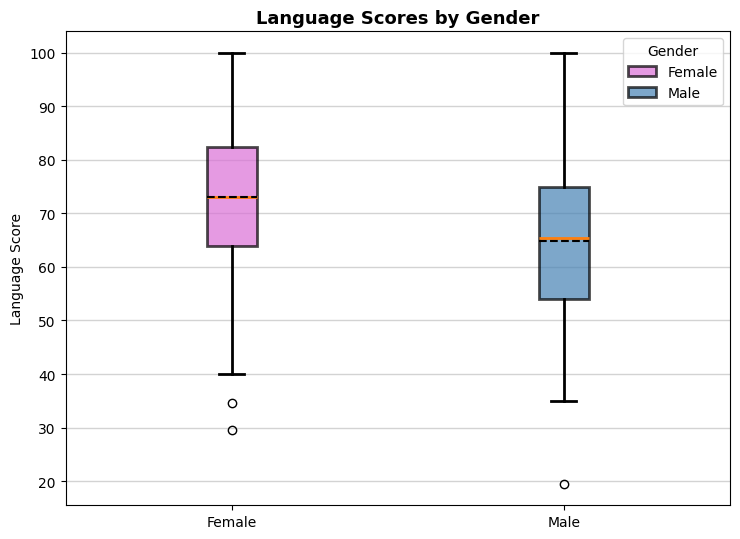

In [37]:
# box plot for language scores by gender
fig, ax = plt.subplots(figsize=(7.5, 5.5))

bp = ax.boxplot(
    [language_female, language_male],
    labels=['Female', 'Male'],
    patch_artist=True,
    showmeans=True,
    meanline=True,
)

colors = ['orchid', 'steelblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_linewidth(2)

for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_linewidth(2)

for mean in bp['means']:
    mean.set_color('black')
    mean.set_linewidth(1.5)
    mean.set_linestyle('--')

ax.set_title('Language Scores by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Language Score')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')
ax.legend(
    [bp['boxes'][0], bp['boxes'][1]],
    ['Female', 'Male'],
    title='Gender',
)

plt.tight_layout()
plt.show()


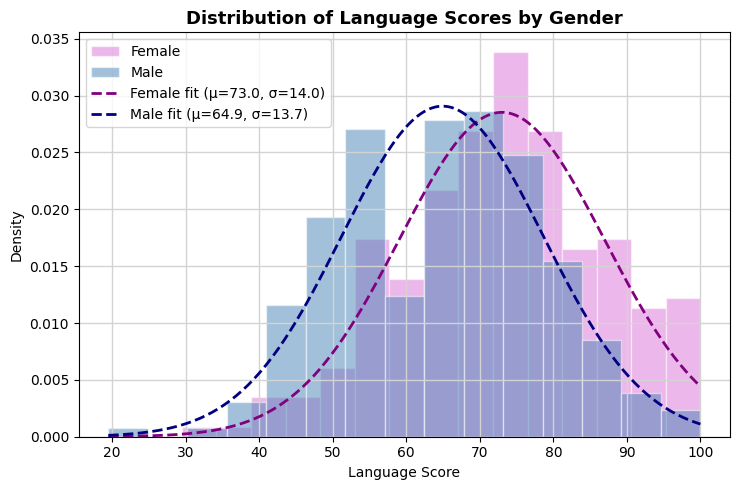

In [38]:
# Histogram of language scores by gender
fig, ax = plt.subplots(figsize=(7.5, 5))

mu_f_lang, std_f_lang = stats.norm.fit(language_female)
mu_m_lang, std_m_lang = stats.norm.fit(language_male)
x_range_lang = np.linspace(min(language_female.min(), language_male.min()), max(language_female.max(), language_male.max()), 200)

ax.hist(language_female, bins=15, density=True, alpha=0.5, color='orchid', edgecolor='white', label='Female')
ax.hist(language_male, bins=15, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Male')
ax.plot(x_range_lang, stats.norm.pdf(x_range_lang, mu_f_lang, std_f_lang), color='purple', linewidth=2, linestyle='--', label=f'Female fit (μ={mu_f_lang:.1f}, σ={std_f_lang:.1f})')
ax.plot(x_range_lang, stats.norm.pdf(x_range_lang, mu_m_lang, std_m_lang), color='navy', linewidth=2, linestyle='--', label=f'Male fit (μ={mu_m_lang:.1f}, σ={std_m_lang:.1f})')

ax.set_title('Distribution of Language Scores by Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Language Score')
ax.set_ylabel('Density')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.xaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')
ax.legend()
plt.tight_layout()
plt.show()


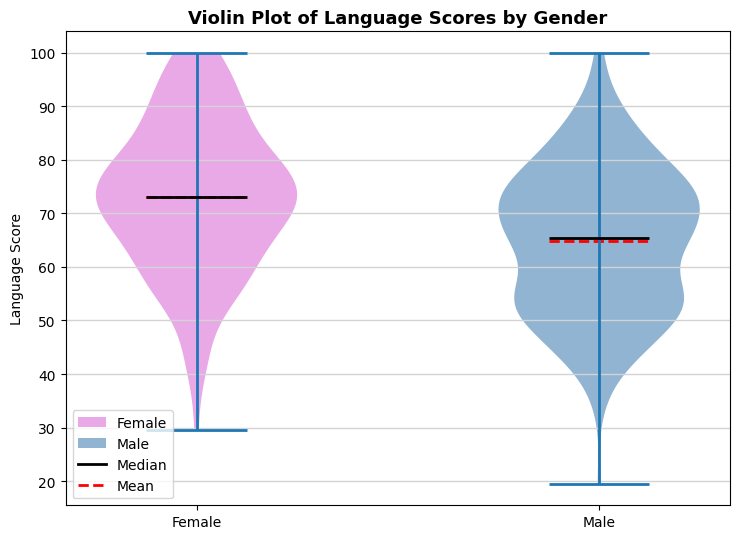

In [39]:
# Violin plot of language scores by gender
fig, ax = plt.subplots(figsize=(7.5, 5.5))

parts = ax.violinplot(
    [language_female, language_male],
    positions=[1, 2],
    showmedians=True,
    showmeans=True,
    showextrema=True,
)

colors = ['orchid', 'steelblue']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

for part in ['cmedians', 'cmeans', 'cbars', 'cmaxes', 'cmins']:
    parts[part].set_linewidth(2)

parts['cmedians'].set_color('black')
parts['cmeans'].set_color('red')
parts['cmeans'].set_linestyle('--')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Female', 'Male'])
ax.set_title('Violin Plot of Language Scores by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Language Score')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='orchid', alpha=0.6, label='Female'),
    Patch(facecolor='steelblue', alpha=0.6, label='Male'),
    Line2D([0], [0], color='black', linewidth=2, label='Median'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Mean'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


In [40]:
X_m_lang = language_male
X_f_lang = language_female

In [41]:
# Check for normality using Shapiro-Wilk test
from scipy.stats import shapiro

stat, p = shapiro(X_m_lang)
print('Shapiro-Wilk Test for Male Students (Language): Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

stat, p = shapiro(X_f_lang)
print('Shapiro-Wilk Test for Female Students (Language): Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Shapiro-Wilk Test for Male Students (Language): Statistics=0.991, p=0.139
Sample looks Gaussian (fail to reject H0)
Shapiro-Wilk Test for Female Students (Language): Statistics=0.990, p=0.085
Sample looks Gaussian (fail to reject H0)


In [42]:
from scipy.stats import levene

# Check for equal variances using Levene's test
stat, p = levene(X_m_lang, X_f_lang)
print('Levene\'s Test (Language): Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Variances are equal (fail to reject H0)')
else:
    print('Variances are not equal (reject H0)')

Levene's Test (Language): Statistics=0.160, p=0.690
Variances are equal (fail to reject H0)


In [43]:
from scipy.stats import ttest_ind
t_stat_lang, p_lang = ttest_ind(X_m_lang, X_f_lang, equal_var=True, alternative='two-sided')
print('Two-sample t-test (Language): t=%.10f, p=%.10f' % (t_stat_lang, p_lang))

Two-sample t-test (Language): t=-6.4086525838, p=0.0000000003


In [44]:
threshold = 0.01
if p_lang < threshold:
    print('Reject the null hypothesis: There is a significant difference in language scores between male and female students.')
else:
    print('Fail to reject the null hypothesis: There is no significant difference in language scores between male and female students.')

Reject the null hypothesis: There is a significant difference in language scores between male and female students.


In [45]:
# We set the significance level at 0.01, which means we are using a 99% confidence level for our test.
# threshold = 0.01 means we are are accepting only a 1% risk of a Type I error, which is:
# - Rejecting the null hypothesis when it is actually true (false positive).
# Type 1 error: Rejecting the null hypothesis when it is actually true (false positive).
# Type 2 error: Failing to reject the null hypothesis when it is actually false (false negative).

# Research Question 2: Is there a difference in scores across parental education levels? If so, which groups differ from each other?

In [46]:
data.parental_level_of_education.value_counts()

parental_level_of_education
associate's degree    354
high school           312
bachelor's degree     188
master's degree       118
Name: count, dtype: int64

In [47]:
# Stats for each parental education level, split by subject
stats_table = data.groupby(['parental_level_of_education', 'subject'])['score'].agg(
    Mean='mean',
    Median='median',
    Std='std',
    Count='count'
).round(2)

stats_table


Mean  Median    Std  Count
parental_level_of_education subject                              
associate's degree          language  70.02    72.0  14.21    177
                            math      67.81    66.0  15.24    177
bachelor's degree           language  72.06    73.0  14.27     94
                            math      68.44    67.0  15.05     94
high school                 language  63.53    65.0  13.40    156
                            math      62.24    63.0  14.04    156
master's degree             language  75.53    76.0  13.55     59
                            math      69.75    73.0  15.15     59

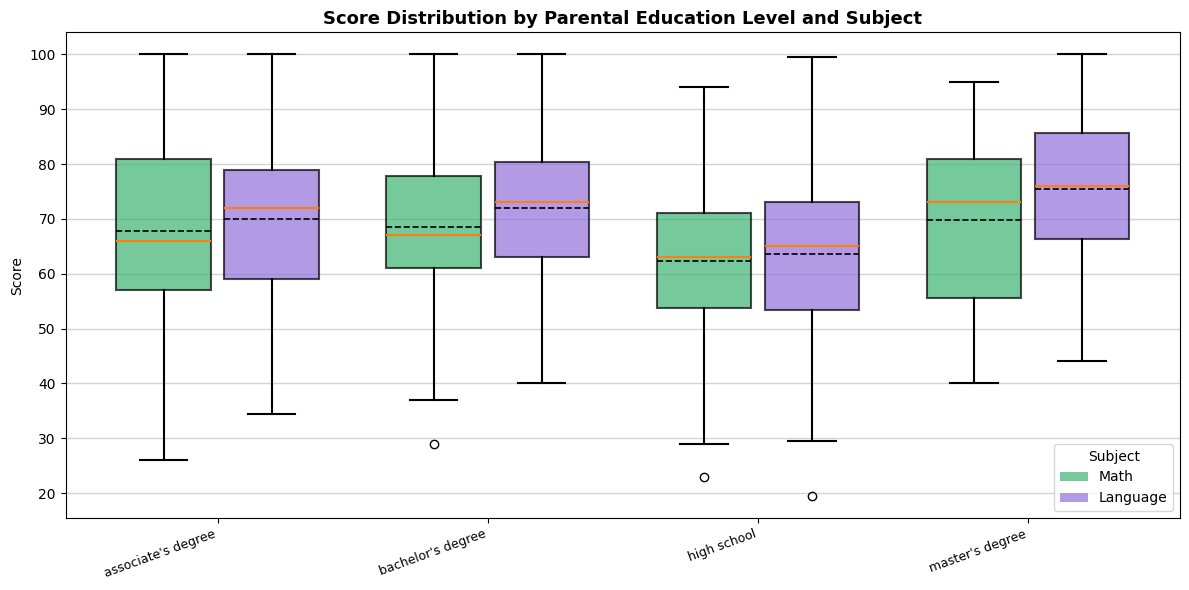

In [48]:
# Boxplot of scores by parental education level, split by subject
edu_levels = data['parental_level_of_education'].unique()
edu_levels_sorted = sorted(edu_levels)

math_groups = [data[(data['parental_level_of_education'] == edu) & (data['subject'] == 'math')]['score'].values
               for edu in edu_levels_sorted]
lang_groups = [data[(data['parental_level_of_education'] == edu) & (data['subject'] == 'language')]['score'].values
               for edu in edu_levels_sorted]

n = len(edu_levels_sorted)
positions_math = np.arange(1, n + 1) - 0.2
positions_lang = np.arange(1, n + 1) + 0.2

fig, ax = plt.subplots(figsize=(12, 6))

bp_math = ax.boxplot(math_groups, positions=positions_math, widths=0.35,
                     patch_artist=True, showmeans=True, meanline=True,
                     manage_ticks=False)
bp_lang = ax.boxplot(lang_groups, positions=positions_lang, widths=0.35,
                     patch_artist=True, showmeans=True, meanline=True,
                     manage_ticks=False)

for patch in bp_math['boxes']:
    patch.set_facecolor('mediumseagreen')
    patch.set_alpha(0.7)
    patch.set_linewidth(1.5)
for patch in bp_lang['boxes']:
    patch.set_facecolor('mediumpurple')
    patch.set_alpha(0.7)
    patch.set_linewidth(1.5)

for bp in [bp_math, bp_lang]:
    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_linewidth(1.5)
    for mean in bp['means']:
        mean.set_color('black')
        mean.set_linewidth(1.2)
        mean.set_linestyle('--')

ax.set_xticks(np.arange(1, n + 1))
ax.set_xticklabels(edu_levels_sorted, rotation=20, ha='right', fontsize=9)
ax.set_title('Score Distribution by Parental Education Level and Subject', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='mediumseagreen', alpha=0.7, label='Math'),
    Patch(facecolor='mediumpurple', alpha=0.7, label='Language'),
]
ax.legend(handles=legend_elements, title='Subject')

plt.tight_layout()
plt.show()


## Hypothesis Testing: One-Way ANOVA — Scores vs Parental Education Level

We test whether mean scores differ across parental education levels, separately for **Math** and **Language**.

- **H0:** The mean score is the same across all parental education levels (μ₁ = μ₂ = ... = μₖ).
- **H1:** At least one parental education level has a different mean score.

### ANOVA assumptions to check first
1. **Independence** of observations (assumed by study design).
2. **Normality** of the score within each group → Shapiro–Wilk test per group.
3. **Homogeneity of variances** across groups → Levene's test.

If normality or equal-variance assumptions are violated, we will use a robust alternative (Welch's ANOVA or the non-parametric Kruskal–Wallis test).

In [49]:
# Build score groups by parental education level for each subject
edu_levels_sorted = sorted(data['parental_level_of_education'].unique())

math_groups_by_edu = {
    edu: data[(data['parental_level_of_education'] == edu) & (data['subject'] == 'math')]['score'].values
    for edu in edu_levels_sorted
}
lang_groups_by_edu = {
    edu: data[(data['parental_level_of_education'] == edu) & (data['subject'] == 'language')]['score'].values
    for edu in edu_levels_sorted
}

print('Group sizes (Math):')
for edu, vals in math_groups_by_edu.items():
    print(f'  {edu:25s} n={len(vals)}')
print('\nGroup sizes (Language):')
for edu, vals in lang_groups_by_edu.items():
    print(f'  {edu:25s} n={len(vals)}')

Group sizes (Math):
  associate's degree        n=177
  bachelor's degree         n=94
  high school               n=156
  master's degree           n=59

Group sizes (Language):
  associate's degree        n=177
  bachelor's degree         n=94
  high school               n=156
  master's degree           n=59


### Assumption 1: Normality within each group (Shapiro–Wilk)

H0: the group sample is drawn from a normal distribution. We reject H0 when p < 0.05.

In [50]:
from scipy.stats import shapiro

def shapiro_per_group(groups_dict, subject_label, alpha=0.05):
    print(f'Shapiro-Wilk normality test — {subject_label}')
    print('-' * 70)
    results = []
    for edu, vals in groups_dict.items():
        stat, p = shapiro(vals)
        normal = p > alpha
        results.append((edu, stat, p, normal))
        flag = 'Normal' if normal else 'NOT normal'
        print(f'  {edu:25s} W={stat:.4f}  p={p:.4f}  -> {flag}')
    return results

shapiro_math = shapiro_per_group(math_groups_by_edu, 'Math')
print()
shapiro_lang = shapiro_per_group(lang_groups_by_edu, 'Language')

Shapiro-Wilk normality test — Math
----------------------------------------------------------------------
  associate's degree        W=0.9846  p=0.0490  -> NOT normal
  bachelor's degree         W=0.9887  p=0.6086  -> Normal
  high school               W=0.9904  p=0.3692  -> Normal
  master's degree           W=0.9559  p=0.0317  -> NOT normal

Shapiro-Wilk normality test — Language
----------------------------------------------------------------------
  associate's degree        W=0.9875  p=0.1202  -> Normal
  bachelor's degree         W=0.9858  p=0.4078  -> Normal
  high school               W=0.9884  p=0.2232  -> Normal
  master's degree           W=0.9816  p=0.5121  -> Normal


### Assumption 2: Homogeneity of variances (Levene's test)

H0: all groups have equal variances. We reject H0 when p < 0.05.

In [51]:
from scipy.stats import levene

stat_lev_math, p_lev_math = levene(*math_groups_by_edu.values(), center='median')
print(f"Levene's test — Math:     W={stat_lev_math:.4f}  p={p_lev_math:.4f}  "
      f"-> {'Equal variances' if p_lev_math > 0.05 else 'UNEQUAL variances'}")

stat_lev_lang, p_lev_lang = levene(*lang_groups_by_edu.values(), center='median')
print(f"Levene's test — Language: W={stat_lev_lang:.4f}  p={p_lev_lang:.4f}  "
      f"-> {'Equal variances' if p_lev_lang > 0.05 else 'UNEQUAL variances'}")

Levene's test — Math:     W=1.2748  p=0.2824  -> Equal variances
Levene's test — Language: W=0.1693  p=0.9171  -> Equal variances


### One-Way ANOVA

If both assumptions hold, we use the classical one-way ANOVA (`f_oneway`).
We also report Welch's ANOVA and Kruskal–Wallis as robustness checks (these do not require equal variances / normality).

In [52]:
from scipy.stats import f_oneway, kruskal

alpha = 0.05

def run_anova(groups_dict, subject_label):
    groups = list(groups_dict.values())
    F, p = f_oneway(*groups)
    H, p_kw = kruskal(*groups)
    print(f'--- {subject_label} ---')
    print(f"One-way ANOVA:    F={F:.4f}  p={p:.6f}")
    print(f"Kruskal-Wallis:   H={H:.4f}  p={p_kw:.6f}  (non-parametric check)")
    if p < alpha:
        print(f"=> Reject H0 at alpha={alpha}: mean scores DIFFER across parental education levels.")
    else:
        print(f"=> Fail to reject H0 at alpha={alpha}: no significant difference in mean scores.")
    print()
    return F, p

F_math, p_math_anova = run_anova(math_groups_by_edu, 'Math')
F_lang, p_lang_anova = run_anova(lang_groups_by_edu, 'Language')

--- Math ---
One-way ANOVA:    F=6.2229  p=0.000375
Kruskal-Wallis:   H=15.6804  p=0.001319  (non-parametric check)
=> Reject H0 at alpha=0.05: mean scores DIFFER across parental education levels.

--- Language ---
One-way ANOVA:    F=14.2406  p=0.000000
Kruskal-Wallis:   H=36.7084  p=0.000000  (non-parametric check)
=> Reject H0 at alpha=0.05: mean scores DIFFER across parental education levels.



In [53]:
# Result: There is a significant difference in mean scores across parental education levels for both math and language subjects, as indicated by the ANOVA results. 
# The Kruskal-Wallis test, which is a non-parametric alternative to ANOVA, 
# also supports this conclusion, suggesting that the differences in scores are not due to random chance.

In [54]:
# Next question: If so, which groups differ from each other?

In [55]:
# Run pairwise comparisons

# total groups
from itertools import combinations
edu_combinations = list(combinations(edu_levels_sorted, 2))
print(f'Total pairwise comparisons: {len(edu_combinations)}\n')
for idx, combo in enumerate(edu_combinations, 1):
    print(f'  {idx}. {combo[0]} vs {combo[1]}')

Total pairwise comparisons: 6

  1. associate's degree vs bachelor's degree
  2. associate's degree vs high school
  3. associate's degree vs master's degree
  4. bachelor's degree vs high school
  5. bachelor's degree vs master's degree
  6. high school vs master's degree


### Why we need multiple-testing correction

The Kruskal-Wallis test only tells us that **at least one** group mean differs. To find out **which** parental education levels differ, we run pairwise comparisons between every pair of groups. With $k = 4$ education levels we get $\binom{4}{2} = 6$ pairwise tests per subject.

Each individual test uses a significance level $\alpha = 0.05$, meaning a 5% chance of a Type I error (false positive) **per test**. When we run many tests, these error probabilities accumulate.

If all $m$ tests were independent and all null hypotheses were true, the probability of getting **at least one** false positive — the **family-wise error rate (FWER)** — is:

$$\text{FWER} = 1 - (1 - \alpha)^m$$

For $m = 6$ and $\alpha = 0.05$:

$$\text{FWER} = 1 - (0.95)^{6} \approx 0.26$$

So there is a ~26% chance of declaring at least one pair "significantly different" purely by chance, even if no real differences exist. Without correction, our reported findings would be unreliable.

To control this, we apply a multiple-testing correction (e.g. **Bonferroni**, which uses $\alpha / m$ per test, or **Tukey's HSD**, designed specifically for all-pairs comparisons after ANOVA, or **Holm / Benjamini–Hochberg** for less conservative control).

### Post-hoc test 1: Tukey's HSD

Tukey's HSD compares all pairs of group means while controlling the family-wise error rate at $\alpha$. It assumes equal variances (which Levene's test confirmed) and is reasonably robust to mild non-normality given moderate group sizes.

In [56]:
from scipy.stats import tukey_hsd

def run_tukey(groups_dict, subject_label, alpha=0.05):
    labels = list(groups_dict.keys())
    groups = list(groups_dict.values())
    res = tukey_hsd(*groups)
    print(f"--- Tukey's HSD — {subject_label} ---")
    print(f"{'Group 1':25s} {'Group 2':25s} {'mean diff':>10s} {'p-value':>10s}  Significant")
    print('-' * 85)
    for i, j in combinations(range(len(labels)), 2):
        mean_diff = np.mean(groups[i]) - np.mean(groups[j])
        p = res.pvalue[i, j]
        sig = 'YES' if p < alpha else 'no'
        print(f"{labels[i]:25s} {labels[j]:25s} {mean_diff:>10.3f} {p:>10.4f}  {sig}")
    print()
    return res

tukey_math = run_tukey(math_groups_by_edu, 'Math')
tukey_lang = run_tukey(lang_groups_by_edu, 'Language')

--- Tukey's HSD — Math ---
Group 1                   Group 2                    mean diff    p-value  Significant
-------------------------------------------------------------------------------------
associate's degree        bachelor's degree             -0.623     0.9877  no
associate's degree        high school                    5.570     0.0037  YES
associate's degree        master's degree               -1.932     0.8217  no
bachelor's degree         high school                    6.193     0.0079  YES
bachelor's degree         master's degree               -1.310     0.9512  no
high school               master's degree               -7.502     0.0055  YES

--- Tukey's HSD — Language ---
Group 1                   Group 2                    mean diff    p-value  Significant
-------------------------------------------------------------------------------------
associate's degree        bachelor's degree             -2.036     0.6596  no
associate's degree        high school         

### Post-hoc test 2: Dunn's test (non-parametric)

Dunn's test is the non-parametric counterpart, appropriate when normality is questionable in some groups. It compares mean ranks between every pair, with a Bonferroni correction applied to control the family-wise error rate across the 6 comparisons.

In [57]:
# Dunn's test (with Bonferroni correction). Requires scikit-posthocs.
try:
    import scikit_posthocs as sp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-posthocs'])
    import scikit_posthocs as sp

def run_dunn(groups_dict, subject_label, alpha=0.05):
    labels = list(groups_dict.keys())
    values = np.concatenate(list(groups_dict.values()))
    group_ids = np.concatenate([[lab] * len(vals) for lab, vals in groups_dict.items()])
    df_long = pd.DataFrame({'score': values, 'group': group_ids})
    p_matrix = sp.posthoc_dunn(df_long, val_col='score', group_col='group', p_adjust='bonferroni')
    p_matrix = p_matrix.loc[labels, labels]

    print(f"--- Dunn's test (Bonferroni-corrected) — {subject_label} ---")
    print(f"{'Group 1':25s} {'Group 2':25s} {'p-adj':>10s}  Significant")
    print('-' * 75)
    for i, j in combinations(range(len(labels)), 2):
        p = p_matrix.iloc[i, j]
        sig = 'YES' if p < alpha else 'no'
        print(f"{labels[i]:25s} {labels[j]:25s} {p:>10.4f}  {sig}")
    print()
    return p_matrix

dunn_math = run_dunn(math_groups_by_edu, 'Math')
dunn_lang = run_dunn(lang_groups_by_edu, 'Language')

--- Dunn's test (Bonferroni-corrected) — Math ---
Group 1                   Group 2                        p-adj  Significant
---------------------------------------------------------------------------
associate's degree        bachelor's degree             1.0000  no
associate's degree        high school                   0.0145  YES
associate's degree        master's degree               1.0000  no
bachelor's degree         high school                   0.0177  YES
bachelor's degree         master's degree               1.0000  no
high school               master's degree               0.0119  YES

--- Dunn's test (Bonferroni-corrected) — Language ---
Group 1                   Group 2                        p-adj  Significant
---------------------------------------------------------------------------
associate's degree        bachelor's degree             1.0000  no
associate's degree        high school                   0.0003  YES
associate's degree        master's degree          

In [58]:
# We go with Dunn's test (Bonferroni-corrected) since some of the groups violates the normality assumption, 
# and Dunn's test is a non-parametric post-hoc test that does not assume normality.

In [59]:
# Summarize significant pairs from Dunn's test for both subjects
def summarize_significant_pairs(p_matrix, subject_label, alpha=0.05):
    labels = list(p_matrix.columns)
    print(f"Significant differences ({subject_label}) at alpha={alpha}:")
    found = False
    for i, j in combinations(range(len(labels)), 2):
        p = p_matrix.iloc[i, j]
        if p < alpha:
            print(f"  - {labels[i]} vs {labels[j]} (p-adj={p:.4f})")
            found = True
    if not found:
        print("  (none)")
    print()

summarize_significant_pairs(dunn_math, 'Math')
summarize_significant_pairs(dunn_lang, 'Language')

Significant differences (Math) at alpha=0.05:
  - associate's degree vs high school (p-adj=0.0145)
  - bachelor's degree vs high school (p-adj=0.0177)
  - high school vs master's degree (p-adj=0.0119)

Significant differences (Language) at alpha=0.05:
  - associate's degree vs high school (p-adj=0.0003)
  - bachelor's degree vs high school (p-adj=0.0001)
  - high school vs master's degree (p-adj=0.0000)



### One Questions Raised:


We know that there is a relation with score and if parents are highschool graduates or other.
Also from our gender-score hypotesis tests We concluded that mean_male_math>mean_femal_math and mean_male_language>mean_femal_language

But we know education level might effect the score, so is the education level distribution of this sample for male and female same?
If there is significance difference in education level dist, this might effect the results and we are having wrong conclusion that gender
effects math and language scores. First lets visualize this

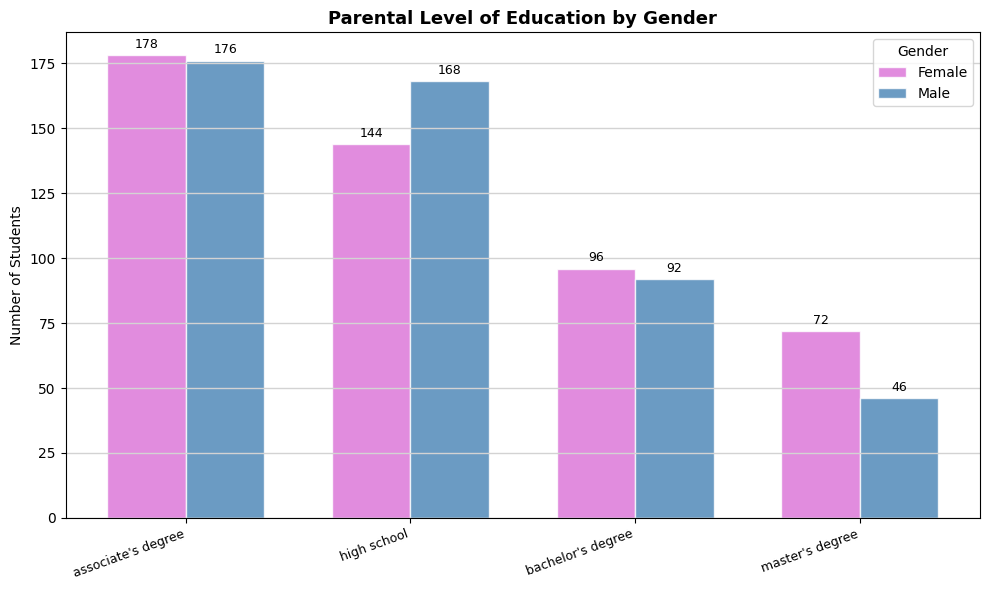

In [60]:
male_students = data[data['gender'] == 'male']
female_students = data[data['gender'] == 'female']

# plot parental level of education for male and female students
edu_order = data['parental_level_of_education'].value_counts().index.tolist()

male_counts = male_students['parental_level_of_education'].value_counts().reindex(edu_order, fill_value=0)
female_counts = female_students['parental_level_of_education'].value_counts().reindex(edu_order, fill_value=0)

x = np.arange(len(edu_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_f = ax.bar(x - width / 2, female_counts.values, width, label='Female', color='orchid', alpha=0.8, edgecolor='white')
bars_m = ax.bar(x + width / 2, male_counts.values, width, label='Male', color='steelblue', alpha=0.8, edgecolor='white')

ax.bar_label(bars_f, padding=3, fontsize=9)
ax.bar_label(bars_m, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(edu_order, rotation=20, ha='right', fontsize=9)
ax.set_title('Parental Level of Education by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Students')
ax.yaxis.grid(True, color='lightgrey', linewidth=1)
ax.set_facecolor('white')
ax.legend(title='Gender')

plt.tight_layout()
plt.show()


In [61]:
# there is a difference in high school level and master levels of parental education between male and female students

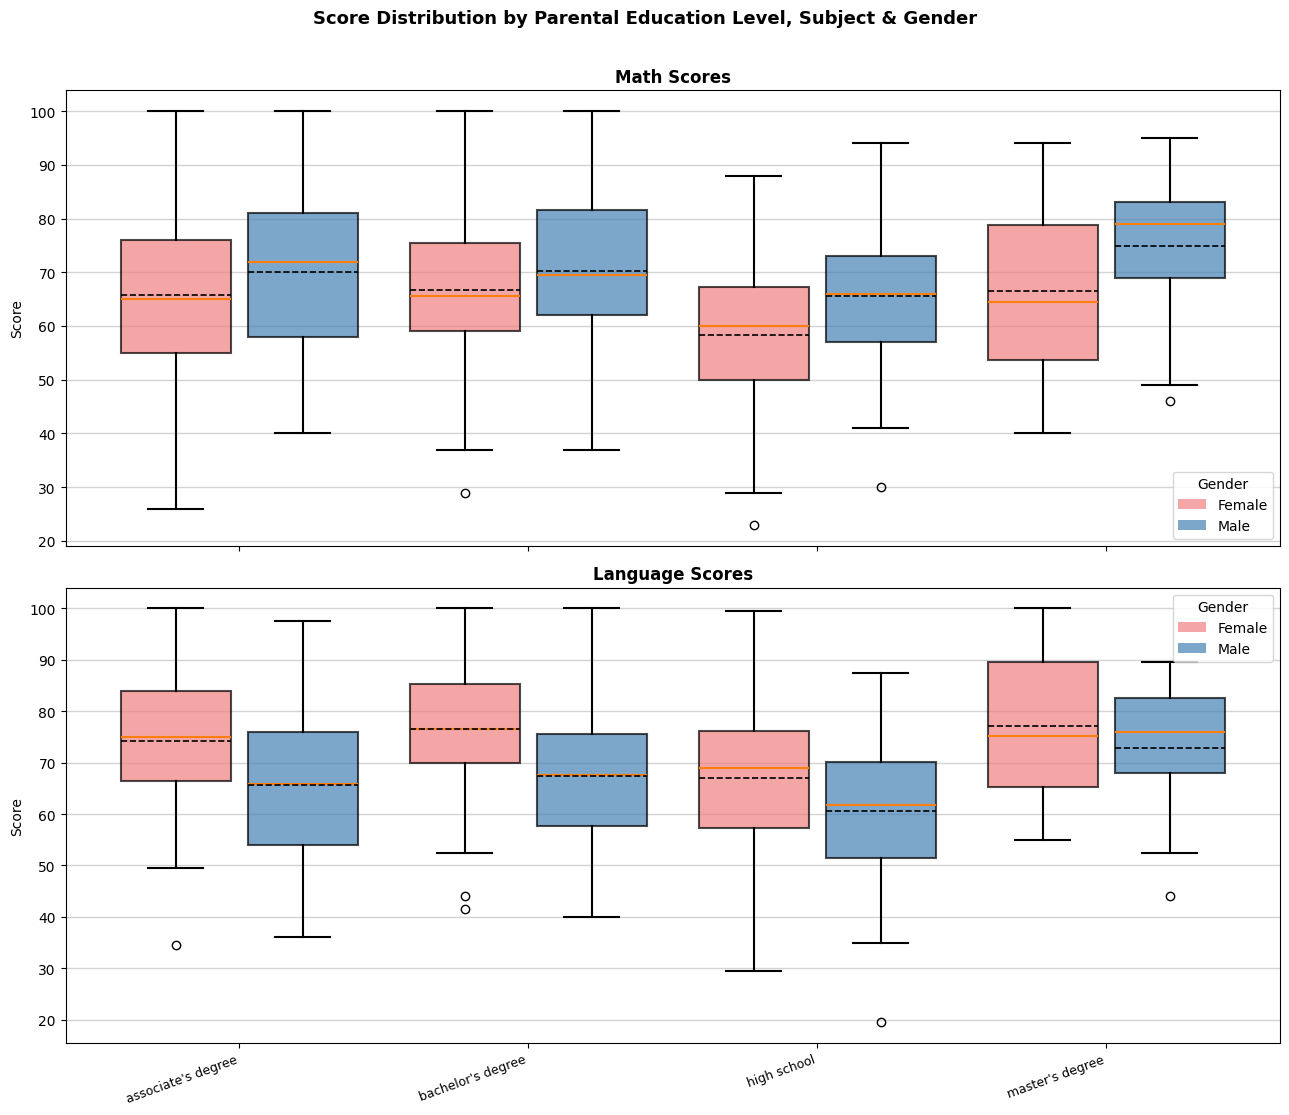

In [62]:
# Boxplot of scores by parental education level, subject, and gender
# Two subplots: Math (top) and Language (bottom), each split by gender per education level
edu_levels_sorted = sorted(data['parental_level_of_education'].unique())
n = len(edu_levels_sorted)

fig, axes = plt.subplots(2, 1, figsize=(13, 11), sharex=True)

subject_configs = [
    ('math',     'Math Scores',     'lightcoral', 'steelblue', axes[0]),
    ('language', 'Language Scores', 'lightcoral', 'steelblue', axes[1]),
]

from matplotlib.patches import Patch

for subject, title, color_f, color_m, ax in subject_configs:
    female_groups = [
        data[(data['parental_level_of_education'] == edu) &
             (data['subject'] == subject) &
             (data['gender'] == 'female')]['score'].values
        for edu in edu_levels_sorted
    ]
    male_groups = [
        data[(data['parental_level_of_education'] == edu) &
             (data['subject'] == subject) &
             (data['gender'] == 'male')]['score'].values
        for edu in edu_levels_sorted
    ]

    pos_f = np.arange(1, n + 1) - 0.22
    pos_m = np.arange(1, n + 1) + 0.22

    bp_f = ax.boxplot(female_groups, positions=pos_f, widths=0.38,
                      patch_artist=True, showmeans=True, meanline=True,
                      manage_ticks=False)
    bp_m = ax.boxplot(male_groups, positions=pos_m, widths=0.38,
                      patch_artist=True, showmeans=True, meanline=True,
                      manage_ticks=False)

    for patch in bp_f['boxes']:
        patch.set_facecolor(color_f)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.5)
    for patch in bp_m['boxes']:
        patch.set_facecolor(color_m)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.5)

    for bp_obj in [bp_f, bp_m]:
        for elem in ['whiskers', 'caps', 'medians']:
            for line in bp_obj[elem]:
                line.set_linewidth(1.5)
        for mean_line in bp_obj['means']:
            mean_line.set_color('black')
            mean_line.set_linewidth(1.2)
            mean_line.set_linestyle('--')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.yaxis.grid(True, color='lightgrey', linewidth=1)
    ax.set_facecolor('white')
    ax.set_xticks(np.arange(1, n + 1))

    legend_elements = [
        Patch(facecolor=color_f, alpha=0.7, label='Female'),
        Patch(facecolor=color_m, alpha=0.7, label='Male'),
    ]
    ax.legend(handles=legend_elements, title='Gender')

axes[1].set_xticklabels(edu_levels_sorted, rotation=20, ha='right', fontsize=9)
fig.suptitle('Score Distribution by Parental Education Level, Subject & Gender',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Stratified gender comparison within each parental education level

To check whether the gender effect on scores holds **within** each parental education level (and is not just an artefact of education-distribution imbalance between genders), we run a separate male-vs-female test for every (education level, subject) cell.

- Per cell, we use Welch's t-test if both subgroups pass Shapiro-Wilk normality, otherwise the non-parametric Mann-Whitney U test.
- We run 4 education levels x 2 subjects = **8 tests**, so we apply a **Bonferroni correction** ($\alpha_{adj} = 0.05 / 8 = 0.00625$) to control the family-wise error rate.

In [63]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

alpha = 0.05
edu_levels_sorted = sorted(data['parental_level_of_education'].unique())
subjects = ['math', 'language']
m_tests = len(edu_levels_sorted) * len(subjects)
alpha_bonf = alpha / m_tests
print(f'Total stratified tests: {m_tests}, Bonferroni-adjusted alpha = {alpha_bonf:.5f}\n')

rows = []
for subject in subjects:
    for edu in edu_levels_sorted:
        sub = data[(data['subject'] == subject) & (data['parental_level_of_education'] == edu)]
        female = sub[sub['gender'] == 'female']['score'].values
        male = sub[sub['gender'] == 'male']['score'].values
        if len(female) < 3 or len(male) < 3:
            rows.append((subject, edu, len(female), len(male), np.nan, np.nan, 'insufficient n', 'no'))
            continue
        _, p_norm_f = shapiro(female)
        _, p_norm_m = shapiro(male)
        if p_norm_f > 0.05 and p_norm_m > 0.05:
            test_name = 't-test'
            stat, p = ttest_ind(male, female, equal_var=False)
        else:
            test_name = 'Mann-Whitney'
            stat, p = mannwhitneyu(male, female, alternative='two-sided')
        mean_diff = np.mean(male) - np.mean(female)
        sig = 'YES' if p < alpha_bonf else 'no'
        rows.append((subject, edu, len(female), len(male), mean_diff, p, test_name, sig))

results_df = pd.DataFrame(rows, columns=['subject', 'parental_education',
                                         'n_female', 'n_male',
                                         'mean_diff (M-F)', 'p_value',
                                         'test', f'sig (p<{alpha_bonf:.4f})'])
results_df

Total stratified tests: 8, Bonferroni-adjusted alpha = 0.00625



,subject,parental_education,n_female,n_male,mean_diff (M-F),p_value,test,sig (p<0.0063)
0,math,associate's degree,89,88,4.280516,0.071760,Mann-Whitney,no
1,math,bachelor's degree,48,46,3.573370,0.251288,t-test,no
2,math,high school,72,84,7.158730,0.001396,t-test,YES
3,math,master's degree,36,23,8.326087,0.032414,t-test,no
4,language,associate's degree,89,88,-8.531090,0.000048,t-test,YES
5,language,bachelor's degree,48,46,-9.182518,0.001465,t-test,YES
6,language,high school,72,84,-6.388889,0.002857,t-test,YES
7,language,master's degree,36,23,-4.352657,0.418836,Mann-Whitney,no


### How to read this table

- **`mean_diff (M-F)`**: positive means males scored higher in that stratum, negative means females scored higher.
- **`p_value`**: raw p-value of the male-vs-female test for that stratum.
- **`sig (p<0.0063)`**: whether the gender difference survives the Bonferroni-corrected threshold.
- **`n_female` / `n_male`**: subgroup sizes - a small `n` means low statistical power, so a non-significant result there should be interpreted cautiously (it may reflect imbalance rather than absence of effect).

If the gender gap that we saw at the overall level disappears within most strata, the original effect was likely driven by **imbalance** in the parental-education distribution. If it remains significant in several strata, the gender effect is robust to that imbalance.